# Dataset 2 - Subset 1 - EMD-Based Connectivity Features for Schizophrenia Detection

This notebook investigates schizophrenia detection on Dataset 2 (Subset 1) using EEG connectivity features extracted after Empirical Mode Decomposition (EMD).

The analysis includes:
- metadata exploration
- subject and phase selection
- EEG segmentation
- EMD-based feature extraction
- connectivity estimation using PLV and PLI
- Random Forest classification and evaluation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PyEMD import EMD
import zipfile
import os
import mne
from joblib import Parallel, delayed
from scipy.signal import hilbert
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score

In [3]:
csv_file_path = "/content/ASZED_SpreadSheet.csv"
df_metadata = pd.read_csv(csv_file_path)

## Metadata Exploration

Before processing EEG signals, the metadata associated with Dataset 2 is explored in order to inspect the distribution of subjects across age, gender, and category.

This step helps better understand the composition of the subset used for classification.

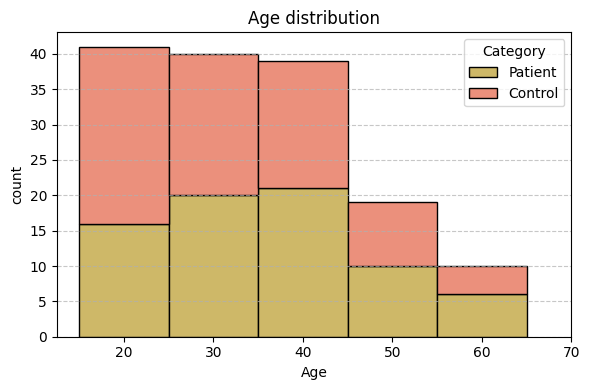

In [ ]:
df_metadata = pd.read_csv(csv_file_path)
categories = ["Patient", "Control"]

colors = {
    "Patient": "#ceb868",  
    "Control": "#eb907c"  
}


bins = [20,30,40,50,60,70]

hist_values = {}
for cat in categories:
    subset_ages = df_metadata.loc[df_metadata["category"] == cat, "age"]
    hist, _ = np.histogram(subset_ages, bins=bins)
    hist_values[cat] = hist

plt.figure(figsize=(6, 4))
bottom = np.zeros(len(bins) - 1, dtype=int)

for cat in categories:
    plt.bar(
        x=bins[:-1],              
        height=hist_values[cat],  
        width=(bins[1] - bins[0]),
        bottom=bottom,             
        color=colors[cat],
        edgecolor="black",
        label=cat
    )
    bottom += hist_values[cat]

plt.xlabel("Age")
plt.ylabel("count")
plt.title("Age distribution")
plt.xticks(bins)  
plt.legend(title="Category")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Age Distribution

The age distribution of patients and controls is visualized to assess the demographic balance of the subset.

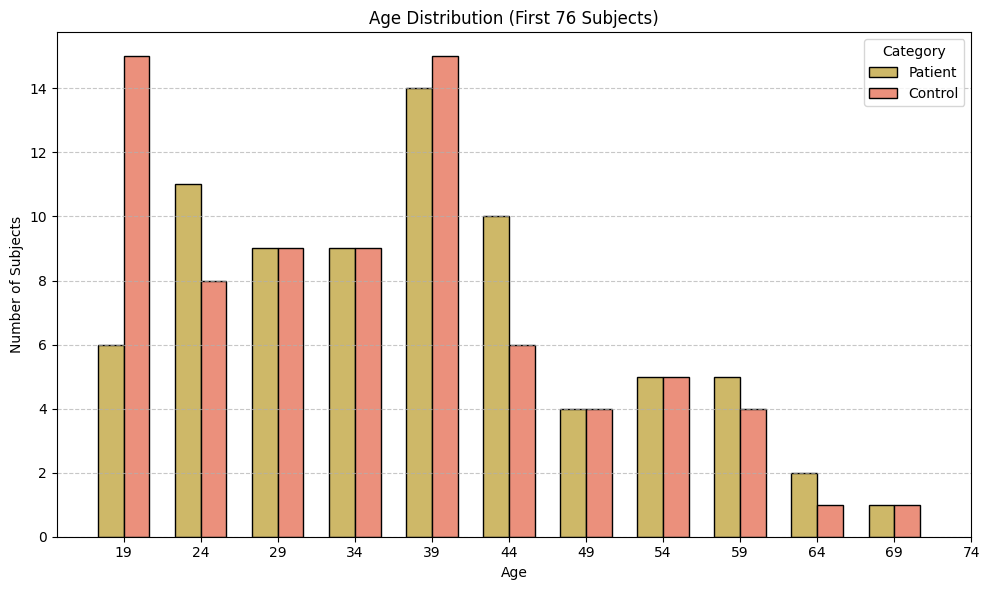

In [ ]:
colors = {"Patient": "#ceb868", "Control": "#eb907c"}
categories = ["Patient", "Control"]

bins = np.arange(int(df_metadata["age"].min()), int(df_metadata["age"].max()) + 5, 5)

plt.figure(figsize=(10, 6))

bar_width = (bins[1] - bins[0]) / (len(categories) + 1)

for i, category in enumerate(categories):
    subset = df_metadata[df_metadata["category"] == category]
    hist, _ = np.histogram(subset["age"], bins=bins)
    plt.bar(
        bins[:-1] + i * bar_width,
        hist,
        width=bar_width,
        label=category,
        color=colors[category],
        edgecolor="black"
    )

plt.xlabel("Age")
plt.ylabel("Number of Subjects")
plt.title("Age Distribution (First 76 Subjects)")
plt.xticks(bins + bar_width / 2, labels=[int(b) for b in bins], rotation=0)
plt.legend(title="Category")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Gender Distribution

The gender distribution is visualized for both schizophrenia patients and healthy controls.

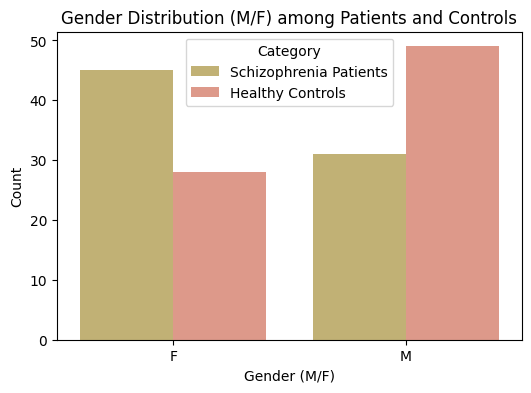

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_metadata, x="gender", hue="category",
              palette={"Patient": "#ceb868", "Control": "#eb907c"})
plt.xlabel("Gender (M/F)")
plt.ylabel("Count")
plt.title("Gender Distribution (M/F) among Patients and Controls")
plt.legend(title="Category", labels=["Schizophrenia Patients", "Healthy Controls"])
plt.show()

In [5]:
zip_file = 'subset_1.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/subset_1')
    print(f"Contenu extrait dans : {os.listdir('/content/subset_1')}")

Contenu extrait dans : ['subset_1']


In [6]:
print(os.listdir("/content/subset_1"))

['subset_1']


In [7]:
print(os.listdir("/content/subset_1/subset_1"))

['subject_42', 'subject_17', 'subject_65', 'subject_54', 'subject_43', 'subject_49', 'subject_74', 'subject_57', 'subject_59', 'subject_51', 'subject_14', 'subject_63', 'subject_41', 'subject_50', 'subject_24', 'subject_61', 'subject_23', 'subject_55', 'subject_66', 'subject_6', 'subject_70', 'subject_18', 'subject_53', 'subject_12', 'subject_73', 'subject_36', 'subject_3', 'subject_7', 'subject_28', 'subject_44', 'subject_16', 'subject_8', 'subject_26', 'subject_22', 'subject_58', 'subject_39', 'subject_62', 'subject_4', 'subject_77', 'subject_11', 'subject_37', 'subject_47', 'subject_2', 'subject_72', 'subject_60', 'subject_76', 'subject_19', 'subject_46', 'subject_69', 'subject_27', 'subject_21', 'subject_78', 'subject_64', 'subject_30', 'subject_20', 'subject_75', 'subject_33', 'subject_38', 'subject_35', 'subject_9', 'subject_45', 'subject_15', 'subject_40', 'subject_48', 'subject_56', 'subject_13', 'subject_25', 'subject_29', 'subject_5', 'subject_31', 'subject_67', 'subject_10',

In [8]:
base_dir = "/content/subset_1/subset_1"

subject_dirs = {}
for subject in os.listdir(base_dir):
    subject_dir = os.path.join(base_dir, subject, "1")
    if os.path.isdir(subject_dir):
        subject_dirs[subject] = subject_dir

print(f"Nombre de sujets avec un dossier '1' trouvé : {len(subject_dirs)}")
for subject, dir_path in subject_dirs.items():
    print(f"{subject} : {dir_path}")

Nombre de sujets avec un dossier '1' trouvé : 76
subject_42 : /content/subset_1/subset_1/subject_42/1
subject_17 : /content/subset_1/subset_1/subject_17/1
subject_65 : /content/subset_1/subset_1/subject_65/1
subject_54 : /content/subset_1/subset_1/subject_54/1
subject_43 : /content/subset_1/subset_1/subject_43/1
subject_49 : /content/subset_1/subset_1/subject_49/1
subject_74 : /content/subset_1/subset_1/subject_74/1
subject_57 : /content/subset_1/subset_1/subject_57/1
subject_59 : /content/subset_1/subset_1/subject_59/1
subject_51 : /content/subset_1/subset_1/subject_51/1
subject_14 : /content/subset_1/subset_1/subject_14/1
subject_63 : /content/subset_1/subset_1/subject_63/1
subject_41 : /content/subset_1/subset_1/subject_41/1
subject_50 : /content/subset_1/subset_1/subject_50/1
subject_24 : /content/subset_1/subset_1/subject_24/1
subject_61 : /content/subset_1/subset_1/subject_61/1
subject_23 : /content/subset_1/subset_1/subject_23/1
subject_55 : /content/subset_1/subset_1/subject_55

In [9]:
categories = {"Patient": [], "Control": []}

def extract_category(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("category="):
            return line.split("=")[1].strip()

for subject in os.listdir(base_dir):
    session_info_path = os.path.join(base_dir, subject, "1", "session_info.gnr")
    if os.path.exists(session_info_path):
        category = extract_category(session_info_path)
        if category in categories:
            categories[category].append(subject)

print(f"Nombre de patients : {len(categories['Patient'])}")
print(f"Nombre de témoins : {len(categories['Control'])}")

print("\nPatients :")
print(categories["Patient"])

print("\nTémoins :")
print(categories["Control"])

Nombre de patients : 52
Nombre de témoins : 24

Patients :
['subject_42', 'subject_65', 'subject_54', 'subject_49', 'subject_74', 'subject_57', 'subject_59', 'subject_51', 'subject_14', 'subject_63', 'subject_41', 'subject_50', 'subject_61', 'subject_23', 'subject_55', 'subject_6', 'subject_70', 'subject_18', 'subject_53', 'subject_73', 'subject_3', 'subject_7', 'subject_16', 'subject_8', 'subject_22', 'subject_58', 'subject_39', 'subject_62', 'subject_4', 'subject_77', 'subject_2', 'subject_72', 'subject_60', 'subject_76', 'subject_69', 'subject_21', 'subject_78', 'subject_64', 'subject_20', 'subject_75', 'subject_9', 'subject_15', 'subject_40', 'subject_48', 'subject_56', 'subject_25', 'subject_5', 'subject_67', 'subject_10', 'subject_52', 'subject_68', 'subject_71']

Témoins :
['subject_17', 'subject_43', 'subject_24', 'subject_66', 'subject_12', 'subject_36', 'subject_28', 'subject_44', 'subject_26', 'subject_11', 'subject_37', 'subject_47', 'subject_19', 'subject_46', 'subject_27'

In [10]:
def segment_signal(signal, fs, window_size=10, overlap=0.5):
    window_samples = int(window_size * fs)
    step = int(window_samples * (1 - overlap))
    segments = []
    for i in range(0, signal.shape[1] - window_samples + 1, step):
        segments.append(signal[:, i:i + window_samples])
    return segments

## EEG Phases and Subject Inclusion

For each subject, three EEG phases are considered:

- Rest
- Arithmetic
- Oddball

Subjects with missing phases are excluded in order to avoid introducing bias or incomplete feature representations.

In [11]:
def load_and_segment_subject(subject, base_dir, window_size=10, overlap=0.5):
    subject_dir = os.path.join(base_dir, subject, "1")
    if not os.path.isdir(subject_dir):
        print(f"Le dossier pour le sujet {subject} n'existe pas.")
        return None

    phases = {
        "Rest": "Phase 1.edf",
        "Arithmetic": "Phase 2.edf",
        "Oddball": "Phase 4.edf"
    }

    segmented_data = {}
    missing_phase = False  #pour indiquer une phase manquante

    for phase_name, phase_file in phases.items():
        phase_path = os.path.join(subject_dir, phase_file)
        if os.path.exists(phase_path):
            raw = mne.io.read_raw_edf(phase_path, preload=True, verbose=False)
            fs = raw.info["sfreq"]
            data = raw.get_data()
            segments = segment_signal(data, fs, window_size, overlap)
            segmented_data[phase_name] = segments
        else:
            print(f"Fichier {phase_file} introuvable pour le sujet {subject}.")
            segmented_data[phase_name] = None
            if phase_name in ["Rest","Arithmetic", "Oddball"]:
                missing_phase = True

    # Exclure les sujets qui manquant des phases pour éviter d'introduire des biais lors de la classification
    if missing_phase:
        print(f"Exclusion du sujet {subject}")
        return None

    return segmented_data


segmented_subjects = {}
excluded_subjects = []

for subject in os.listdir(base_dir):
    try:
        data = load_and_segment_subject(subject, base_dir, window_size=10, overlap=0.5)
        if data is not None:
            segmented_subjects[subject] = data
        else:
            excluded_subjects.append(subject)
    except Exception as e:
        print(f"Erreur sur {subject} : {e}")
        excluded_subjects.append(subject)

print(f"\nNombre total de sujets traités : {len(segmented_subjects)}")
print(f"Sujets exclus : {excluded_subjects}")

Fichier Phase 4.edf introuvable pour le sujet subject_42.
Exclusion du sujet subject_42
Fichier Phase 2.edf introuvable pour le sujet subject_23.
Fichier Phase 4.edf introuvable pour le sujet subject_23.
Exclusion du sujet subject_23
Fichier Phase 4.edf introuvable pour le sujet subject_6.
Exclusion du sujet subject_6
Fichier Phase 2.edf introuvable pour le sujet subject_37.
Fichier Phase 4.edf introuvable pour le sujet subject_37.
Exclusion du sujet subject_37
Fichier Phase 4.edf introuvable pour le sujet subject_20.
Exclusion du sujet subject_20
Fichier Phase 4.edf introuvable pour le sujet subject_9.
Exclusion du sujet subject_9

Nombre total de sujets traités : 70
Sujets exclus : ['subject_42', 'subject_23', 'subject_6', 'subject_37', 'subject_20', 'subject_9']


In [12]:
def compute_plv(phase1, phase2):

    phase_diff = phase1 - phase2
    return np.abs(np.mean(np.exp(1j * phase_diff)))

def compute_pli(phase1, phase2):

    phase_diff = phase1 - phase2
    return np.abs(np.mean(np.sign(np.sin(phase_diff))))

In [ ]:
def extract_imf_features(segment):
    n_channels = segment.shape[0]
    emd = EMD()
    imfs_list = []
    phases_list = []

    for ch in range(n_channels):
        signal = segment[ch, :]
        imfs = emd.emd(signal)
        imfs_list.append(imfs)
        phases = [np.angle(hilbert(imf)) for imf in imfs]
        phases_list.append(phases)

    n_imfs_common = min(imfs.shape[0] for imfs in imfs_list)
    connectivity_features = {}

    for imf_idx in range(n_imfs_common):
        phases_for_imf = [phases_list[ch][imf_idx] for ch in range(n_channels)]

        plv_matrix = np.zeros((n_channels, n_channels))
        pli_matrix = np.zeros((n_channels, n_channels))

        for i in range(n_channels):
            for j in range(i+1, n_channels):
                plv_val = compute_plv(phases_for_imf[i], phases_for_imf[j])
                pli_val = compute_pli(phases_for_imf[i], phases_for_imf[j])
                plv_matrix[i, j] = plv_val
                plv_matrix[j, i] = plv_val
                pli_matrix[i, j] = pli_val
                pli_matrix[j, i] = pli_val

        connectivity_features[f"IMF_{imf_idx+1}"] = {
            "PLV": plv_matrix,
            "PLI": pli_matrix
        }

    return connectivity_features

## Feature Vector Construction

For each IMF, PLV and PLI connectivity matrices are computed across channels.

To build a compact representation, summary statistics are extracted from the connectivity matrices and concatenated into a fixed-length feature vector.

A fixed number of IMFs is retained for all samples to ensure a consistent feature size.

In [ ]:
def flatten_features(imf_features, n_imfs_fixed=3):
    feature_vector = []
    keys = sorted(imf_features.keys(), key=lambda x: int(x.split('_')[1]))

    for i in range(n_imfs_fixed):
        if i < len(keys):
            key = keys[i]
            plv_matrix = imf_features[key]["PLV"]
            pli_matrix = imf_features[key]["PLI"]
            mean_plv = np.mean(plv_matrix)
            mean_pli = np.mean(pli_matrix)
            feature_vector.extend([mean_plv, mean_pli])
        else:
            feature_vector.extend([0, 0])
    return feature_vector

In [15]:
X = []
y = []
subject_infos = []

for subject, phases_data in segmented_subjects.items():
    label = 1 if subject in categories["Patient"] else 0
    for phase_name, segments in phases_data.items():
        if segments is not None:
            for seg_idx, segment in enumerate(segments):
                imf_features = extract_imf_features(segment)
                feature_vector = flatten_features(imf_features, n_imfs_fixed=3)
                X.append(feature_vector)
                y.append(label)
                subject_infos.append((subject, phase_name, seg_idx))

X = np.array(X)
y = np.array(y)

print("Dimensions de la matrice de caractéristiques :", X.shape)
print("Dimensions du vecteur des labels :", y.shape)

Dimensions de la matrice de caractéristiques : (723, 6)
Dimensions du vecteur des labels : (723,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train set :", X_train.shape, "Test set :", X_test.shape)

Dimensions de la matrice de caractéristiques : (723, 6)
Dimensions du vecteur des labels : (723,)
Train set : (578, 6) Test set : (145, 6)


In [ ]:
print(len(X_test))

145


**Random Forest**

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :\n", cm)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, digits=4))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Matrice de confusion :
 [[13 28]
 [ 7 97]]

Rapport de classification :
              precision    recall  f1-score   support

           0     0.6500    0.3171    0.4262        41
           1     0.7760    0.9327    0.8472       104

    accuracy                         0.7586       145
   macro avg     0.7130    0.6249    0.6367       145
weighted avg     0.7404    0.7586    0.7281       145

Accuracy : 0.7586206896551724


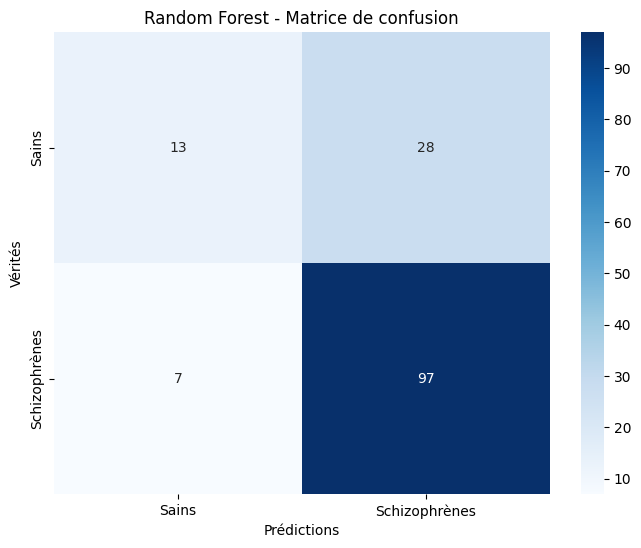

In [ ]:
conf_matrix_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Sains", "Schizophrènes"], yticklabels=["Sains", "Schizophrènes"])
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Random Forest - Matrice de confusion")
plt.show()

## Hyperparameter Optimization

A grid search is performed to identify suitable Random Forest hyperparameters, including:

- number of trees
- maximum depth
- minimum number of samples per leaf
- class weighting

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': ['balanced', {0:2, 1:1}]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'class_weight': {0: 2, 1: 1}, 'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 100}


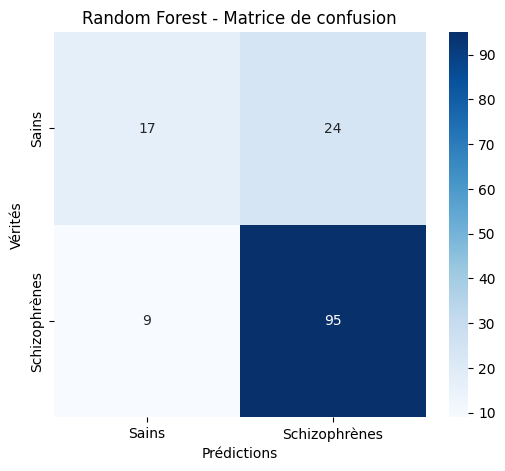


Rapport de classification :
               precision    recall  f1-score   support

        Sains       0.65      0.41      0.51        41
Schizophrènes       0.80      0.91      0.85       104

     accuracy                           0.77       145
    macro avg       0.73      0.66      0.68       145
 weighted avg       0.76      0.77      0.75       145

accuracy : 0.7724137931034483


In [ ]:
rf = RandomForestClassifier(
    class_weight={0: 2, 1: 1},  # Penaliser les erreurs sur la classe 0 
    max_depth=10,
    min_samples_leaf=2,
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

labels = ["Sains", "Schizophrènes"]
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Random Forest - Matrice de confusion")
plt.show()

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=labels))
print("accuracy :", accuracy_score(y_test, y_pred))

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_model = rf = RandomForestClassifier(
    class_weight={0: 2, 1: 1},  
    max_depth=10,
    min_samples_leaf=2,
    n_estimators=100,
    random_state=42
)
rf_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='accuracy')
print(f"Random Forest - KFold CV scores: {rf_scores}")
print(f"Random Forest - Mean CV accuracy: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

Random Forest - KFold CV scores: [0.80689655 0.71034483 0.74482759 0.73611111 0.68055556]
Random Forest - Mean CV accuracy: 0.736 ± 0.042
